In [133]:
import numpy as np

In [134]:
X = np.array([
    [-2, -2],
    [-1.5, -2],
    [-2, -1.5],

    [2, 2],
    [1.5, 2],
    [2, 1.5],

    [-2, 2],
    [-1.5, 2],
    [-2, 1.5]
])

y = np.array([
    0, 0, 0,
    1, 1, 1,
    2, 2, 2
])
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (9, 2)
y shape: (9,)


In [135]:
y = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2])
H = np.eye(3)[y]
print(H)

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [136]:

W1 = np.random.randn(2,3)*0.1
W2 = np.random.randn(3,3)*0.1
b1 = np.zeros(3)
b2 = np.zeros(3)
Z1 = X@W1+b1
A1 = np.maximum(Z1, 0)
Z2 = A1@W2+b2
print(A1)
print(Z2)


[[0.         0.02407959 0.        ]
 [0.         0.02304402 0.        ]
 [0.         0.01909525 0.        ]
 [0.17316032 0.         0.73266955]
 [0.10609483 0.         0.60892669]
 [0.19693574 0.         0.67324502]
 [0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]]
[[ 3.11001507e-03 -2.60044579e-03  1.36170564e-04]
 [ 2.97626632e-03 -2.48861149e-03  1.30314437e-04]
 [ 2.46626005e-03 -2.06216864e-03  1.07984050e-04]
 [ 9.17705843e-02 -3.75396760e-02 -1.15341070e-01]
 [ 6.97671833e-02 -3.10177641e-02 -9.29408959e-02]
 [ 9.08313393e-02 -3.46766689e-02 -1.08905977e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]


In [137]:
def softmax(ap):
    b = ap - np.max(ap, axis = 1, keepdims = True)
    ex = np.exp(b)
    return ex / np.sum(ex, axis = 1, keepdims = True)
A2 = softmax(Z2)
print(A2)


[[0.33429875 0.33239519 0.33330607]
 [0.33425721 0.33243551 0.33330728]
 [0.33409883 0.33258931 0.33331186]
 [0.37152206 0.32645692 0.30202102]
 [0.3631126  0.32830007 0.30858733]
 [0.37023399 0.32656441 0.30320159]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]]


In [138]:
def cross_entropy(a,ap):
    ep = 1e-15
    ap = np.clip(ap,ep,1-ep)
    return -np.sum(a * np.log(ap))
print("loss:", cross_entropy(H,A2))

loss: 9.936132637039798


In [139]:

def backprop():
    global W1, b1, W2, b2
    lr = 0.01
    for i in range(1000):
    
        
        Z1 = X @ W1 + b1
        A1 = np.maximum(Z1, 0)
    
        Z2 = A1 @ W2 + b2
        A2 = softmax(Z2)
    
        
        loss = cross_entropy(H, A2)
    
        if i % 10 == 0:
            print(i, loss)
    
        
        dZ2 = A2 - H
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0)
    
        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * (Z1 > 0)
    
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0)
    
        
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
   
backprop()


    

0 9.936132637039798
10 9.49168299494307
20 8.519608989574945
30 6.625027414960557
40 4.687114624382469
50 3.5095971830564285
60 2.8058485827320365
70 2.3441339994602712
80 2.004415911923383
90 1.7387367917113241
100 1.5270830403456932
110 1.3542700142247128
120 1.2116842572023931
130 1.0927685037110477
140 0.9924711325928278
150 0.9068683171837091
160 0.8331999842599078
170 0.7694366397109942
180 0.7136911512635297
190 0.6649409999439789
200 0.6218569360187325
210 0.5835610919132164
220 0.5491897123397531
230 0.5184581364205612
240 0.4906338429162074
250 0.4655400457394803
260 0.44261216336041354
270 0.4217855409979455
280 0.4026184112292328
290 0.3850379891489609
300 0.36886710915204657
310 0.3539445409657602
320 0.3400487934267685
330 0.32714428516526045
340 0.31518985267188465
350 0.30403414104316473
360 0.2934987493793936
370 0.28372995876190077
380 0.2745600300164421
390 0.2658504187611054
400 0.2577325592204014
410 0.25007411202871754
420 0.2427644892239521
430 0.2359212806124432

In [140]:
Z1 = X @ W1 + b1
A1 = np.maximum(Z1, 0)

Z2 = A1 @ W2 + b2
A2 = softmax(Z2)

In [141]:
predictions = np.argmax(A2, axis=1)

print(predictions)
print(y)
print(A2)

[0 0 0 1 1 1 2 2 2]
[0 0 0 1 1 1 2 2 2]
[[9.99682038e-01 2.65600218e-05 2.91401500e-04]
 [9.99114068e-01 6.39477752e-05 8.21984458e-04]
 [9.98166666e-01 1.19187832e-04 1.71414620e-03]
 [4.01831448e-05 9.99686344e-01 2.73472367e-04]
 [1.70421804e-04 9.98189871e-01 1.63970730e-03]
 [9.64104371e-05 9.99107444e-01 7.96145878e-04]
 [1.35918689e-02 1.33415133e-02 9.73066618e-01]
 [1.35918689e-02 1.33415133e-02 9.73066618e-01]
 [1.35918689e-02 1.33415133e-02 9.73066618e-01]]


In [144]:
X_new = np.array([
    [-1.7, -1.8],   
    [-2.3, -2.1],   

    [1.8, 1.7],     
    [2.3, 2.1],     

    [-1.8, 1.7],    
    [-2.2, 2.3]    
])
Z1_new = X_new @ W1 + b1
A1_new = np.maximum(Z1_new, 0)

Z2_new = A1_new @ W2 + b2
A2_new = softmax(Z2_new)

prediction = np.argmax(A2_new, axis=1)

print(A2_new)
print(prediction)


[[9.98814969e-01 8.20394624e-05 1.10299128e-03]
 [9.99878705e-01 1.16058004e-05 1.09688993e-04]
 [1.21092533e-04 9.98815903e-01 1.06300423e-03]
 [1.41643238e-05 9.99910493e-01 7.53429417e-05]
 [1.35918689e-02 1.33415133e-02 9.73066618e-01]
 [1.35918689e-02 1.33415133e-02 9.73066618e-01]]
[0 0 1 1 2 2]


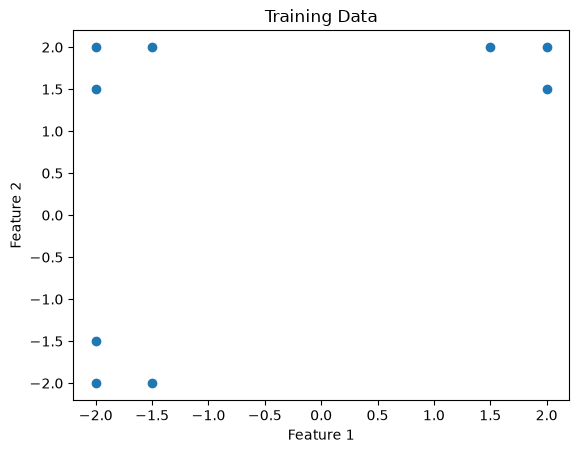

In [145]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data")

plt.show()

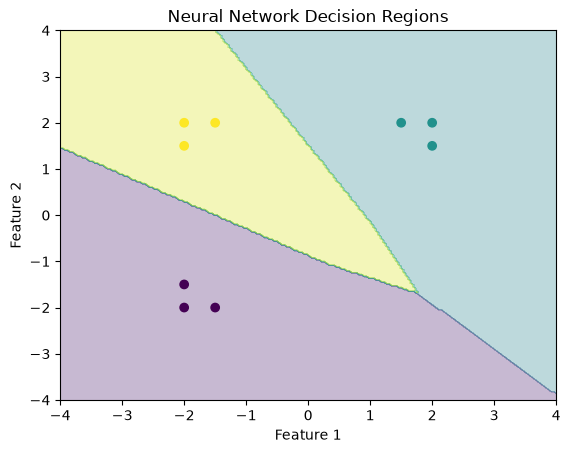

In [146]:
import numpy as np
import matplotlib.pyplot as plt

# Create lots of points covering the whole area
x1 = np.linspace(-4, 4, 200)
x2 = np.linspace(-4, 4, 200)

xx, yy = np.meshgrid(x1, x2)

grid = np.c_[xx.ravel(), yy.ravel()]

# Run the grid through your trained network
Z1_grid = grid @ W1 + b1
A1_grid = np.maximum(Z1_grid, 0)

Z2_grid = A1_grid @ W2 + b2
A2_grid = softmax(Z2_grid)

pred_grid = np.argmax(A2_grid, axis=1)

# Put predictions back into a 2D grid
pred_grid = pred_grid.reshape(xx.shape)

# Plot decision regions
plt.contourf(xx, yy, pred_grid, alpha=0.3)

# Plot original training points
plt.scatter(X[:, 0], X[:, 1], c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Neural Network Decision Regions")

plt.show()

In [147]:
X_test = np.array([
    [0, 0],
    [-0.5, -0.5],
    [0.5, 0.5],
    [-0.5, 0.5],
    [0.5, -0.5],

    [-1, 0],
    [0, -1],
    [1, 0],
    [0, 1],

    [-1, 1],
    [1, 1],
    [-1, -1],
    [1, -1]
])
Z1_new = X_test @ W1 + b1
A1_new = np.maximum(Z1_new, 0)

Z2_new = A1_new @ W2 + b2
A2_new = softmax(Z2_new)

prediction = np.argmax(A2_new, axis=1)

print(A2_new)
print(prediction)

[[0.0495094  0.04237587 0.90811473]
 [0.42126563 0.01420499 0.56452938]
 [0.01700107 0.39893817 0.58406076]
 [0.02193308 0.0197012  0.95836571]
 [0.10690966 0.08678197 0.80630837]
 [0.25905872 0.01629678 0.7246445 ]
 [0.60478668 0.01090559 0.38430772]
 [0.01388834 0.57660657 0.40950509]
 [0.01850693 0.24511594 0.73637713]
 [0.01359187 0.01334151 0.97306662]
 [0.00384173 0.91922078 0.07693749]
 [0.92275833 0.00287387 0.0743678 ]
 [0.20529977 0.1580457  0.63665454]]
[2 2 2 2 2 2 0 1 2 2 1 0 2]


In [148]:
X_test = np.array([
    [-10, -10],
    [10, 10],
    [-10, 10],
    [10, -10],

    [-20, 0],
    [20, 0],
    [0, -20],
    [0, 20]
])
Z1_new = X_test @ W1 + b1
A1_new = np.maximum(Z1_new, 0)

Z2_new = A1_new @ W2 + b2
A2_new = softmax(Z2_new)

prediction = np.argmax(A2_new, axis=1)

print(A2_new)
print(prediction)

[[1.00000000e+00 7.45191985e-22 8.53676278e-24]
 [2.94281969e-21 1.00000000e+00 3.56206394e-24]
 [1.35918689e-02 1.33415133e-02 9.73066618e-01]
 [7.71291227e-01 2.28708503e-01 2.69957063e-07]
 [1.00000000e+00 1.94373946e-16 2.10483723e-17]
 [3.25657272e-26 1.00000000e+00 1.85458774e-30]
 [1.00000000e+00 2.75150335e-27 2.93748560e-30]
 [2.75846406e-16 1.00000000e+00 6.04691175e-18]]
[0 1 2 0 0 1 0 1]
